--- Đang huấn luyện mô hình giám sát ---


c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,Model,F1-Score,PR-AUC
0,Logistic Regression,0.985075,0.975081
1,Random Forest,0.985075,0.974821
2,XGBoost,0.977444,0.975843



--- Biểu đồ so sánh hiệu năng các mô hình ---


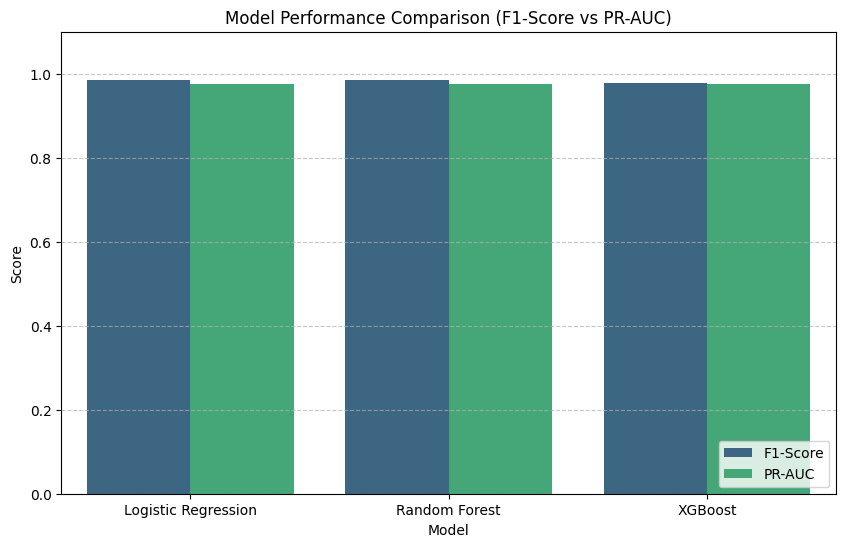

✅ Đã lưu biểu đồ so sánh vào: outputs/figures/model_performance_comparison.png
✅ Hoàn thành huấn luyện mô hình và đã lưu vào outputs/models


In [1]:
import sys
import os
import pandas as pd
import joblib
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
sys.path.append(os.path.abspath(".."))

from src.data.loader import load_config
from src.models.supervised import train_classification, train_regression
from src.evaluation.metrics import evaluate_model

# 1. Chuẩn bị dữ liệu
config = load_config("../configs/params.yaml")
df = pd.read_csv("../data/processed/cleaned_data.csv")

# Cột 'Type' thường chứa 'L', 'M', 'H'. Chúng ta dùng Mapping để giữ thứ tự quan trọng.
if 'Type' in df.columns:
    type_map = {'L': 0, 'M': 1, 'H': 2}
    df['Type'] = df['Type'].map(type_map).fillna(-1)

# --- ĐOẠN QUAN TRỌNG: KIỂM TRA VÀ XỬ LÝ NaN ---
nan_total = df.isnull().sum().sum()
if nan_total > 0:
    print(f"⚠️ Phát hiện {nan_total} giá trị NaN.")
    # Điền giá trị trung vị (median) cho các cột số thay vì xóa dòng
    numeric_cols = df.select_dtypes(include=['number']).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    
    # Nếu vẫn còn NaN (ở cột object), lúc này mới xóa nốt
    df = df.dropna()
    print(f"✅ Sau khi xử lý, còn lại {len(df)} dòng.")

# Kiểm tra khẩn cấp: Nếu df trống thì dừng lại báo lỗi luôn
if len(df) == 0:
    raise ValueError("❌ LỖI: Dữ liệu đang trống rỗng! Hãy kiểm tra lại file cleaned_data.csv hoặc logic mapping.")

# Loại bỏ cột 'Product ID' nếu nó còn tồn tại (vì nó là chuỗi định danh, không dùng huấn luyện)
if 'Product ID' in df.columns:
    df = df.drop(columns=['Product ID'])
    
# Xử lý tên cột để tránh lỗi XGBoost (xóa các ký tự [ ] <)
df.columns = [re.sub(r'[\[\]<]', '', col) for col in df.columns]

X = df.drop(columns=[config['features']['target']])
y = df[config['features']['target']]

# Chia dữ liệu (Lưu ý: stratify=y để giữ tỷ lệ lỗi máy đồng đều)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Huấn luyện Phân lớp (Classification)
print("--- Đang huấn luyện mô hình giám sát ---")
# Lưu ý: Chuyền .values vào nếu hàm trong src chưa xử lý để tránh lỗi tên cột
model_lr, model_rf, model_xgb = train_classification(X_train, y_train, config)

# 3. Đánh giá và lưu bảng so sánh
results = []
for name, model in [("Logistic Regression", model_lr), 
                     ("Random Forest", model_rf), 
                     ("XGBoost", model_xgb)]:
    f1, pr_auc = evaluate_model(model, X_test.values, y_test)
    results.append({"Model": name, "F1-Score": f1, "PR-AUC": pr_auc})

performance_df = pd.DataFrame(results)
display(performance_df)

print("\n--- Biểu đồ so sánh hiệu năng các mô hình ---")

# Chuyển đổi dữ liệu sang định dạng "Long format" để vẽ biểu đồ bằng Seaborn
viz_df = performance_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=viz_df, x="Model", y="Score", hue="Metric", palette="viridis")

plt.title("Model Performance Comparison (F1-Score vs PR-AUC)")
plt.ylim(0, 1.1) # Để trục y hiển thị từ 0 đến 1
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Lưu biểu đồ vào outputs/figures
plt.savefig("../outputs/figures/model_performance_comparison.png", bbox_inches='tight')
plt.show()

print("✅ Đã lưu biểu đồ so sánh vào: outputs/figures/model_performance_comparison.png")
# ----------------------------------

# BỔ SUNG: Lưu bảng kết quả vào outputs/tables
performance_df.to_csv("../outputs/tables/supervised_performance_comparison.csv", index=False)

# 4. Huấn luyện Hồi quy (Dự đoán Tool wear)
# Tìm lại tên cột chính xác sau khi đã clean (ví dụ: Tool wear min)
tool_wear_col = [c for c in df.columns if 'Tool wear' in c][0]
y_reg = df[tool_wear_col]
X_reg = df.drop(columns=[tool_wear_col, config['features']['target']])
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

model_tool_wear = train_regression(X_train_r, y_train_r, config)

# BỔ SUNG: Lưu các mô hình vật lý vào outputs/models
joblib.dump(model_xgb, '../outputs/models/model_xgb.pkl')
joblib.dump(model_rf, '../outputs/models/model_rf.pkl')
joblib.dump(model_tool_wear, '../outputs/models/model_tool_wear_reg.pkl')

print("✅ Hoàn thành huấn luyện mô hình và đã lưu vào outputs/models")